# Dataset Analysis and Molecule Comparison Pipeline

This notebook provides the dataset analysis across molecular complexity and documents the core logic and code which was used to compare predicted molecular structures
against the ground-truth structure for each test compound.

## Setup

In [1]:
import json
from pathlib import Path
from statistics import mean
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.offsetbox import TextArea, HPacker, AnnotationBbox
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap


from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import rdFingerprintGenerator, rdDepictor, rdCoordGen
from rdkit.Chem.rdMolDescriptors import CalcMolFormula
from rdkit.Chem.Draw import rdMolDraw2D

RDLogger.DisableLog("rdApp.*")   # silence RDKit parse warnings for malformed candidate SMILES

# ---------- colour palette for the figures ----------
GREEN  = {"band": "#EDF4F3", "solid": "#7FA8A3", "cap": "#AECBC7", "edge": "#5E8B82"}
ORANGE = {"band": "#FAF2E9", "solid": "#D8A47F", "cap": "#E8C7A9", "edge": "#B07D4F"}
ENS_EDGE      = "#8A5A33"
SPEC_ENS_EDGE = "#3F655C"

# ---------- global figure style (applies to every chart below) ----------
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 7.5,
    "axes.linewidth": 0.8, "figure.dpi": 150,
    "axes.spines.top": False, "axes.spines.right": False,
})
DPI = 300   # export resolution used by save_fig

## Dataset

The dataset is `results/combined_predictions_105_final.json`. Its structure is three levels deep:

```
{ class_name: { entry_id: { ...record... } } }
```

Each **record** holds:

| field | meaning |
|---|---|
| `compound_id` | unique id of the test molecule |
| `smiles` | **ground-truth** structure (what every method is trying to recover) |
| `n_complex` | a precomputed complexity score for the molecule |
| one key per **method** | a list of predicted SMILES, **best-first** (position = rank) |

The method keys are four specialized models and six LLMs. We flatten the nested JSON into a flat list
of records, keeping the class label so we can break results down by chemical class later.

In [2]:
# Method columns
SPECIALIZED = ["odan_ai", "nmrpeak", "nmr_solver", "nmrmind"]
LLM         = ["gemini", "gpt", "grok", "qwen", "claude", "deepseek"]
METHODS     = SPECIALIZED + LLM

# Human-readable labels
DISPLAY = {
    "odan_ai": "BLIND", "nmrpeak": "NMRPeak", "nmr_solver": "NMR-Solver", "nmrmind": "NMRMind",
    "gemini": "Gemini 3.1 Pro", "gpt": "GPT-5.5", "grok": "Grok 4.3",
    "qwen": "Qwen3.7-Max", "claude": "Claude Opus 4.8", "deepseek": "DeepSeek-V4-Pro",
}

# Locate the repo root from wherever the notebook is opened, then load the JSON.
ROOT = Path.cwd()
while not (ROOT / "results" / "combined_predictions_105_final.json").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA_PATH = ROOT / "results" / "combined_predictions_105_final.json"

raw = json.loads(DATA_PATH.read_text(encoding="utf-8"))

records = []
for cls_name, entries in raw.items():
    for entry_id, e in entries.items():
        records.append({
            "cls": cls_name,
            "entry_id": entry_id,
            "compound_id": e.get("compound_id"),
            "truth": e.get("smiles"),                       # ground-truth SMILES
            "n_complex": e.get("n_complex"),
            "preds": {m: (e.get(m) or []) for m in METHODS},  # ranked candidate list per method
        })

print(f"Loaded {len(records)} molecules across {len(raw)} classes from {DATA_PATH.name}")

# Figures are written here at the export DPI (DPI, set in Setup).
TO_ARTICLE = ROOT / "analysis" / "to_article"
TO_ARTICLE.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    """Save a deliverable figure into analysis/to_article at the export DPI."""
    fig.savefig(TO_ARTICLE / f"{name}.png", dpi=DPI, bbox_inches="tight")

Loaded 105 molecules across 21 classes from combined_predictions_105_final.json


## Canonicalization and structural matching

Two SMILES strings can describe the *same* molecule yet differ character-by-character (different atom
order, aromatic perception, or stereo annotation). To compare structures we map each SMILES to its
RDKit canonical form with stereochemistry removed.

Two molecules are considered the same when their canonical (stereo-stripped) SMILES are identical.

In [3]:
def canonical(smi, strip_stereo=True):
    """RDKit canonical SMILES; stereochemistry stripped by default. Returns None if unparseable."""
    if not smi:
        return None
    m = Chem.MolFromSmiles(smi)
    if m is None:                      # malformed SMILES (some LLM candidates are invalid)
        return None
    if strip_stereo:
        Chem.RemoveStereochemistry(m)
    try:
        return Chem.MolToSmiles(m)
    except Exception:
        return None


def same_molecule(smi_a, smi_b):
    """True if two SMILES denote the same molecule (stereo-independent graph match)."""
    ca = canonical(smi_a)
    cb = canonical(smi_b)
    return ca is not None and ca == cb

## Tanimoto similarity

The Tanimoto coefficient measures structural overlap between two molecules from their
Morgan (ECFP) fingerprints.
We used Morgan radius 2 fingerprints (`fpSize = 2048`), the common
ECFP4 descriptor.

In [4]:
FP_RADIUS = 2        # Morgan radius 2 == ECFP4
FP_SIZE   = 2048
_MORGAN   = rdFingerprintGenerator.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_SIZE)


def tanimoto(smi_a, smi_b):
    """Tanimoto similarity from Morgan radius-2 (ECFP4) fingerprints. None if either SMILES is unparseable."""
    ma, mb = Chem.MolFromSmiles(smi_a or ""), Chem.MolFromSmiles(smi_b or "")
    if ma is None or mb is None:
        return None
    return DataStructs.TanimotoSimilarity(_MORGAN.GetFingerprint(ma), _MORGAN.GetFingerprint(mb))

## Top-1 / Top-10 hits

Each method returns its candidates **best-first**, so the candidate at list index `i` has
**rank = i + 1**. We scan the list and take the rank of the *first* candidate that matches the truth:

- `hit_rank` → the 1-based rank of the correct molecule, or `None` if it never appears.
- A method scores a **Top-k hit** when `hit_rank ≤ k` (the truth is among the first *k* candidates).

By definition every Top-1 hit is also a Top-10 hit, so the rates are monotonic in *k*.
Aggregating over all molecules gives each method's Top-1/10 **hit rate** (the denominator is all
105 molecules, so an empty or all-wrong list simply counts as a miss).

In [5]:
TOPK = (1, 10)


def hit_rank(truth, candidates):
    """1-based rank of the first candidate equal to the truth (stereo-independent); None on a miss.

    The candidate's position in the list is its rank: index 0 -> rank 1, index 1 -> rank 2, ...
    """
    t = canonical(truth)
    if t is None or not candidates:
        return None
    for i, smi in enumerate(candidates):
        if canonical(smi) == t:
            return i + 1
    return None


def hit_at_k(truth, candidates, k):
    """True if the truth appears within the first k candidates (hit_rank <= k)."""
    r = hit_rank(truth, candidates)
    return r is not None and r <= k


def topk_flags(truth, candidates, ks=TOPK):
    """Per-k boolean hit flags for one (truth, candidate-list) pair, e.g. {1: False, 10: True}."""
    r = hit_rank(truth, candidates)
    return {k: (r is not None and r <= k) for k in ks}

### Molecular-complexity distribution

Distribution of the machine-learned molecular-complexity score (`n_complex`; [Chem. Sci. 2025, D4SC07320G](https://doi.org/10.1039/D4SC07320G)) over the 105 benchmark molecules. The set sits well inside the difficult range (mean 4.07) and spreads across the whole complexity axis rather than clustering at the easy end.

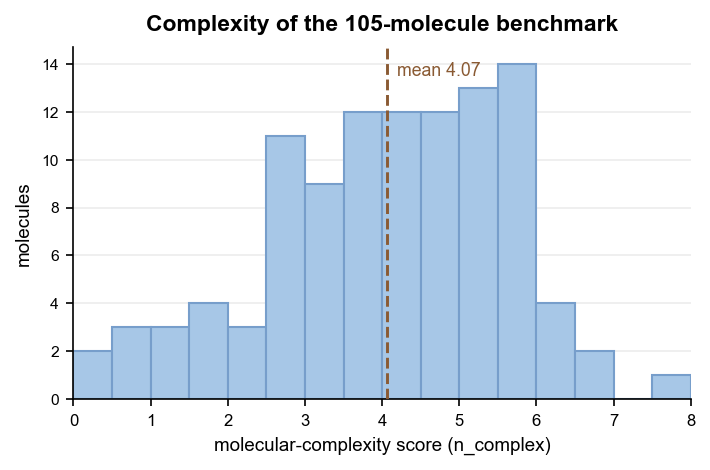

In [6]:
cx = np.array([r["n_complex"] for r in records], float)

fig, ax = plt.subplots(figsize=(4.9, 3.3))
fig.subplots_adjust(left=0.12, right=0.96, top=0.88, bottom=0.17)
pastel_blue = "#A7C7E7"
pastel_pink = "#779ECB"
ax.hist(cx, bins=np.arange(0, 8.5, 0.5), color=pastel_blue, edgecolor=pastel_pink, linewidth=1.0, zorder=2)
ax.axvline(cx.mean(), color=ENS_EDGE, ls="--", lw=1.4, zorder=3)
ax.text(cx.mean() + 0.12, ax.get_ylim()[1] * 0.96, f"mean {cx.mean():.2f}",
        color=ENS_EDGE, fontsize=8.5, va="top", ha="left")
ax.set_xlim(0, 8); ax.set_xlabel("molecular-complexity score (n_complex)"); ax.set_ylabel("molecules")
ax.yaxis.grid(True, color="#ececec", lw=0.8); ax.set_axisbelow(True)
ax.set_title("Complexity of the 105-molecule benchmark", fontsize=11, fontweight="bold", pad=8)
save_fig(fig, "fig_dataset_complexity_105")
plt.show()

### Complexity vs the NMR-Challenge set

The same complexity score computed for the 112 molecules of the external NMR-Challenge benchmark ([J. Chem. Inf. Model. 2026, 66, 11, 6299–6312](https://doi.org/10.1021/acs.jcim.6c00481), `dataset/complexities_nmr_challenge.json`). Our set is ~4.4× more complex on average (4.07 vs 0.93) and 62 of 105 molecules exceed the single hardest NMR-Challenge molecule (score 3.81).

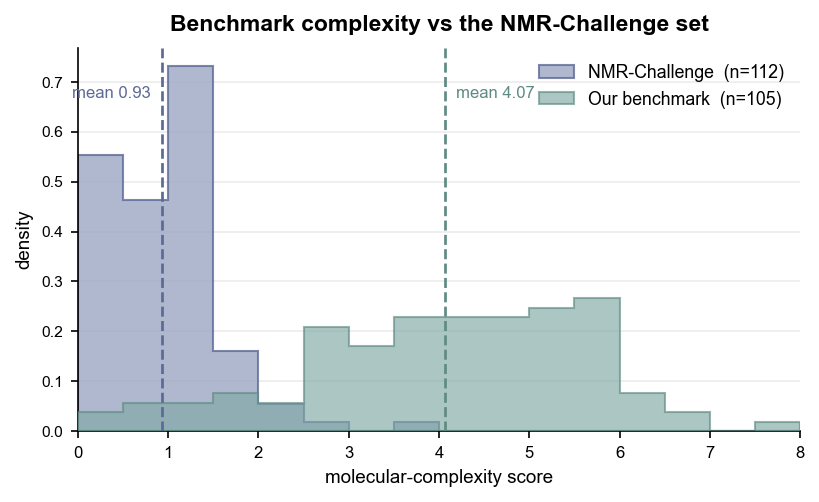

In [7]:
ours = np.array([r["n_complex"] for r in records], float)
chal = np.array(list(json.loads((ROOT / "dataset" / "complexities_nmr_challenge.json").read_text(encoding="utf-8")).values()), float)

CHAL = {"solid": "#9BA7C4", "edge": "#5C6A96"}
bins = np.arange(0, 8.5, 0.5)

fig, ax = plt.subplots(figsize=(5.6, 3.6))
fig.subplots_adjust(left=0.11, right=0.97, top=0.87, bottom=0.16)
ax.hist(chal, bins=bins, density=True, histtype="stepfilled", color=CHAL["solid"], edgecolor=CHAL["edge"],
        lw=1.1, alpha=0.80, zorder=2, label=f"NMR-Challenge  (n={len(chal)})")
ax.hist(ours, bins=bins, density=True, histtype="stepfilled", color=GREEN["solid"], edgecolor=GREEN["edge"],
        lw=1.1, alpha=0.65, zorder=3, label=f"Our benchmark  (n={len(ours)})")
ax.axvline(chal.mean(), color=CHAL["edge"],  ls="--", lw=1.3, zorder=4)
ax.axvline(ours.mean(), color=GREEN["edge"], ls="--", lw=1.3, zorder=4)
ymax = ax.get_ylim()[1]
ax.text(chal.mean() - 0.12, ymax * 0.90, f"mean {chal.mean():.2f}", color=CHAL["edge"],  fontsize=8, ha="right", va="top")
ax.text(ours.mean() + 0.12, ymax * 0.90, f"mean {ours.mean():.2f}", color=GREEN["edge"], fontsize=8, ha="left",  va="top")
ax.set_xlim(0, 8); ax.set_xlabel("molecular-complexity score"); ax.set_ylabel("density")
ax.yaxis.grid(True, color="#ececec", lw=0.8); ax.set_axisbelow(True)
ax.legend(loc="upper right", frameon=False, fontsize=8.5)
ax.set_title("Benchmark complexity vs the NMR-Challenge set", fontsize=11, fontweight="bold", pad=8)
save_fig(fig, "fig_dataset_complexity_vs_challenge")
plt.show()

## Analysis

### Top-1 / 10 hit rate by method

For every method we compute the fraction of the 105 molecules whose ground-truth structure is
recovered within the first *k* candidates (*k* = 1, 10). A miss or an empty prediction list simply
counts as 0, so the denominator is always the full set of molecules, the rates are therefore directly
comparable across methods. Methods are grouped into specialized models and LLMs; within
each method the two shades show how the hit rate grows as the candidate list is allowed to be longer. The final column is the mean Top-1 Tanimoto similarity (Morgan radius 2)
— how structurally close each method's best guess is to the truth even when it is not an exact hit
(not defined for the ensemble).

We also add oracles with LLM and specialized model ensemble: for each molecule we keep the best result across all six LLMs
(the smallest hit rank any LLM achieves). This is an upper bound on the LLMs collectively, what they
could deliver if one always knew which model to trust for a given spectrum, so it is drawn set apart and
hatched, not as a deployable single predictor.

In [8]:
def topk_rate_table(records, methods=METHODS, ks=TOPK):
    """Per-method Top-k hit rate as a percentage of all molecules (misses included in the denominator)."""
    n = len(records)
    rows = []
    for m in methods:
        hits = {k: 0 for k in ks}
        tani = []                                          # Top-1 Tanimoto (rank-1 candidate vs truth)
        for rec in records:
            r = hit_rank(rec["truth"], rec["preds"][m])
            for k in ks:
                if r is not None and r <= k:
                    hits[k] += 1
            cands = rec["preds"][m]
            if cands:
                t = tanimoto(rec["truth"], cands[0])
                if t is not None:
                    tani.append(t)
        rows.append({"method": m, "label": DISPLAY[m],
                     "kind": "specialized" if m in SPECIALIZED else "LLM",
                     **{f"top{k}": 100.0 * hits[k] / n for k in ks},
                     "tanimoto_r2": (mean(tani) if tani else float("nan"))})
    return pd.DataFrame(rows)


def ensemble_hit_rank(rec, methods):
    """Oracle ensemble: the best (smallest) hit rank any of `methods` achieves for this molecule."""
    ranks = [hit_rank(rec["truth"], rec["preds"][m]) for m in methods]
    ranks = [r for r in ranks if r is not None]
    return min(ranks) if ranks else None


summary = topk_rate_table(records)

# Oracle LLM ensemble: per molecule, take the best-ranked correct answer across all LLMs.
n = len(records)
ens_ranks = [ensemble_hit_rank(rec, LLM) for rec in records]
ens_row = {"method": "llm_ensemble", "label": "LLM ensemble", "kind": "ensemble",
           **{f"top{k}": 100.0 * sum(r is not None and r <= k for r in ens_ranks) / n for k in TOPK}}
summary = pd.concat([summary, pd.DataFrame([ens_row])], ignore_index=True)

# Oracle specialized ensemble: per molecule, the best-ranked correct answer across all specialized models.
spec_ens_ranks = [ensemble_hit_rank(rec, SPECIALIZED) for rec in records]
spec_ens_row = {"method": "spec_ensemble", "label": "Specialized ensemble", "kind": "ensemble",
                **{f"top{k}": 100.0 * sum(r is not None and r <= k for r in spec_ens_ranks) / n for k in TOPK}}
summary = pd.concat([summary, pd.DataFrame([spec_ens_row])], ignore_index=True)
summary.round({"top1": 1, "top10": 1, "tanimoto_r2": 2})

,method,label,kind,top1,top10,tanimoto_r2
0,odan_ai,BLIND,specialized,48.6,68.6,0.74
1,nmrpeak,NMRPeak,specialized,48.6,50.5,0.70
2,nmr_solver,NMR-Solver,specialized,20.0,27.6,0.46
3,nmrmind,NMRMind,specialized,0.0,1.0,0.17
4,gemini,Gemini 3.1 Pro,LLM,20.0,23.8,0.52
5,gpt,GPT-5.5,LLM,12.4,18.1,0.43
6,grok,Grok 4.3,LLM,11.4,13.3,0.42
7,qwen,Qwen3.7-Max,LLM,8.6,15.2,0.41
8,claude,Claude Opus 4.8,LLM,4.8,13.3,0.39
9,deepseek,DeepSeek-V4-Pro,LLM,1.9,2.9,0.30


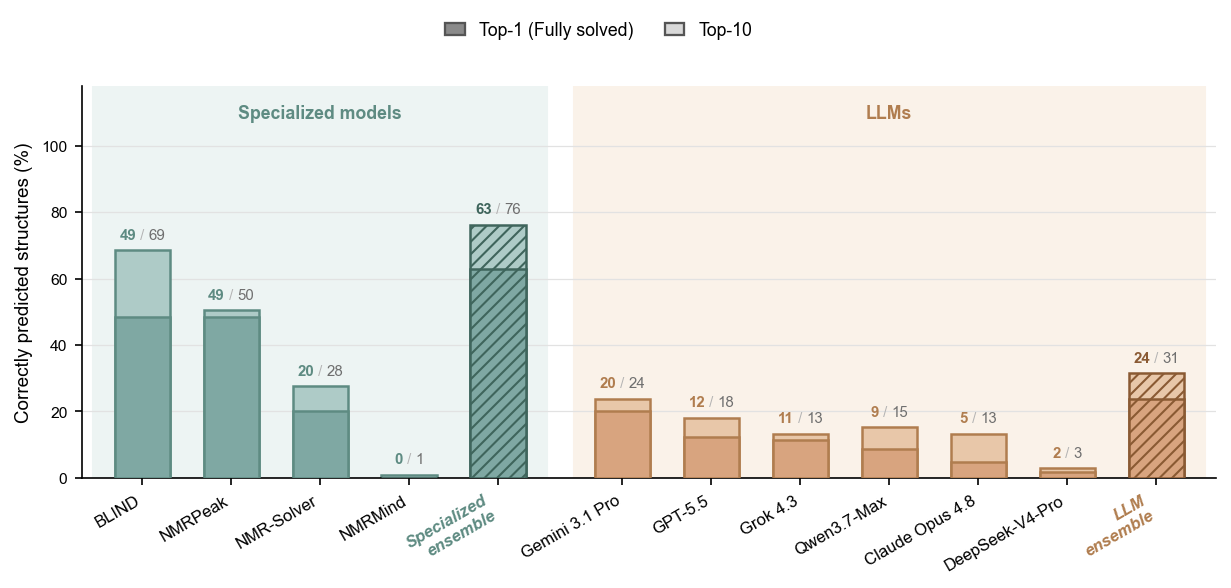

In [9]:
# light cap = Top-10 reach, solid = Top-1 solved
PAL = {"specialized": dict(cap=GREEN["cap"],  solid=GREEN["solid"],  edge=GREEN["edge"]),
       "LLM":         dict(cap=ORANGE["cap"], solid=ORANGE["solid"], edge=ORANGE["edge"])}
ENS_PAL   = dict(cap=ORANGE["cap"], solid=ORANGE["solid"], edge=ENS_EDGE)
SPEC_ENS_PAL = dict(cap=GREEN["cap"], solid=GREEN["solid"], edge=SPEC_ENS_EDGE)
BAND      = {"specialized": GREEN["band"], "LLM": ORANGE["band"]}
GROUP_INK = {"specialized": GREEN["edge"], "LLM": ORANGE["edge"]}
SPEC_ENS = "spec_ensemble"
ENS      = "llm_ensemble"
ENS_SET  = (SPEC_ENS, ENS)

order = list(SPECIALIZED) + [SPEC_ENS] + list(LLM) + [ENS]
S = summary.set_index("method").loc[order]
group = ["specialized" if (m in SPECIALIZED or m == SPEC_ENS) else "LLM" for m in order]

x, pos = [], 0.0
for m in order:
    if m == LLM[0]:
        pos += 0.4
    x.append(pos); pos += 1.0
x = np.array(x)

bw = 0.62
fig, ax = plt.subplots(figsize=(8.4, 3.9))
fig.subplots_adjust(top=0.87, bottom=0.20, left=0.09, right=0.99)

for kind in ("specialized", "LLM"):
    idx = [i for i, g in enumerate(group) if g == kind]
    ax.axvspan(x[idx[0]] - 0.55, x[idx[-1]] + 0.55, color=BAND[kind], zorder=0)

for xi, m in zip(x, order):
    is_ens = m in ENS_SET
    p = (SPEC_ENS_PAL if m == SPEC_ENS else ENS_PAL if m == ENS
         else PAL["specialized" if m in SPECIALIZED else "LLM"])
    hatch = "////" if is_ens else None
    t1, t10 = S.loc[m, "top1"], S.loc[m, "top10"]
    ax.bar(xi, t10, bw, color=p["cap"],   edgecolor=p["edge"], linewidth=1.2, hatch=hatch, zorder=2)
    ax.bar(xi, t1,  bw, color=p["solid"], edgecolor=p["edge"], linewidth=1.2, hatch=hatch, zorder=3)
    boxes = [TextArea(f"{t1:.0f}",  textprops=dict(color=p["edge"], fontweight="bold", fontsize=7.2)),
             TextArea(" / ",        textprops=dict(color="#b3b3b3", fontsize=7.2)),
             TextArea(f"{t10:.0f}", textprops=dict(color="#6f6f6f", fontsize=7.2))]
    pack = HPacker(children=boxes, align="baseline", pad=0, sep=0)
    ax.add_artist(AnnotationBbox(pack, (xi, t10), xybox=(0, 4), xycoords="data",
                                 boxcoords="offset points", box_alignment=(0.5, 0.0), frameon=False, pad=0))

for kind, name in (("specialized", "Specialized models"), ("LLM", "LLMs")):
    idx = [i for i, g in enumerate(group) if g == kind]
    ax.text(x[idx].mean(), 107, name, ha="center", va="bottom",
            fontsize=8.5, fontweight="bold", color=GROUP_INK[kind])

ax.set_xticks(x)
xt_labels = [S.loc[m, "label"].replace(" ensemble", "\nensemble") if m in ENS_SET else S.loc[m, "label"] for m in order]
ax.set_xticklabels(xt_labels, rotation=30, ha="right")
for lab, m in zip(ax.get_xticklabels(), order):
    if m in ENS_SET:
        ink = GROUP_INK["specialized"] if m == SPEC_ENS else GROUP_INK["LLM"]
        lab.set_fontweight("bold"); lab.set_style("italic"); lab.set_color(ink)
ax.set_ylabel("Correctly predicted structures (%)")
ax.set_ylim(0, 118)
ax.set_yticks(range(0, 101, 20))
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="#E2E2E2", linewidth=0.6)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.margins(x=0.01)

handles = [Patch(facecolor="#8a8a8a", edgecolor="#555555", linewidth=1.1, label="Top-1 (Fully solved)"),
           Patch(facecolor="#d9d9d9", edgecolor="#555555", linewidth=1.1, label="Top-10")]
fig.legend(handles=handles, loc="center", bbox_to_anchor=(0.5, 0.965),
           ncol=2, frameon=False, handlelength=1.1, columnspacing=1.8, fontsize=8.5)
save_fig(fig, "fig_topk_accuracy")
plt.show()

### Top-1 wrong-but-valid predictions: right formula?

Restricting to each method's Top-1 (rank-1) prediction, we look at those whose SMILES is valid (RDKit parses it) yet incorrect (not the true structure) — the Top-1 wrong-but-valid cases.

For those we measure whether the prediction has the correct brutto formula, tallied per model and then macro-averaged within each class.

In [10]:
def formula(smi):
    """Hill molecular (brutto) formula, e.g. 'C7H8O'; None if unparseable."""
    m = Chem.MolFromSmiles(smi)
    return CalcMolFormula(m) if m is not None else None


def wrong_but_valid_row(m):
    """Per-model tally over each method's Top-1 candidate: wrong-but-valid count, and of those
    the share with a correct brutto formula (percentage)."""
    wbv = brutto_ok = 0
    for rec in records:
        cands = rec["preds"][m]
        if not cands:                                # method returned nothing for this molecule
            continue
        s = cands[0]                                 # Top-1 (rank-1) candidate only
        c = canonical(s)
        if c is None or c == canonical(rec["truth"]):   # invalid structure, or actually the correct molecule
            continue
        wbv += 1
        brutto_ok += (formula(s) == formula(rec["truth"]))
    return {"method": m, "label": DISPLAY[m],
            "kind": "Specialized" if m in SPECIALIZED else "LLM",
            "wbv": wbv,
            "brutto_pct": 100.0 * brutto_ok / wbv if wbv else float("nan")}


wbv_per_model = pd.DataFrame([wrong_but_valid_row(m) for m in METHODS])

wbv_summary = pd.DataFrame([
    {"Class": kind,
     "Models": int((wbv_per_model.kind == kind).sum()),
     "Top-1 wrong-but-valid (total)":     int(wbv_per_model.loc[wbv_per_model.kind == kind, "wbv"].sum()),
     "Top-1 wrong-but-valid (per model)": round(wbv_per_model.loc[wbv_per_model.kind == kind, "wbv"].mean(), 1),
     "Correct brutto formula, %":         round(wbv_per_model.loc[wbv_per_model.kind == kind, "brutto_pct"].mean(), 1)}
    for kind in ("Specialized", "LLM")])
wbv_summary

,Class,Models,Top-1 wrong-but-valid (total),Top-1 wrong-but-valid (per model),"Correct brutto formula, %"
0,Specialized,4,296,74.0,7.4
1,LLM,6,458,76.3,6.0


### How models fail: the most agreed-upon wrong structures

For each model we take its rank-1 answer, keep the ones that are a valid molecule but **not** the true structure, and group
identical wrong structures proposed for the same spectrum. Sorting by how many models independently
produced the same wrong molecule surfaces the consensus errors — the traps a whole family of
methods falls into together. Each panel pairs the true structure (green) with the structure the models
converged on (orange).

Two opposite pictures emerge. The LLMs repeatedly make the same mistakes — all five agree on
dropping a nitrile or a diazo group, and four of five read bromine as chlorine.

*DeepSeek and NMRMind are excluded from this view* — DeepSeek returns no parseable structure for most
spectra and NMRMind's output is not chemically meaningful, so neither contributes informative errors.

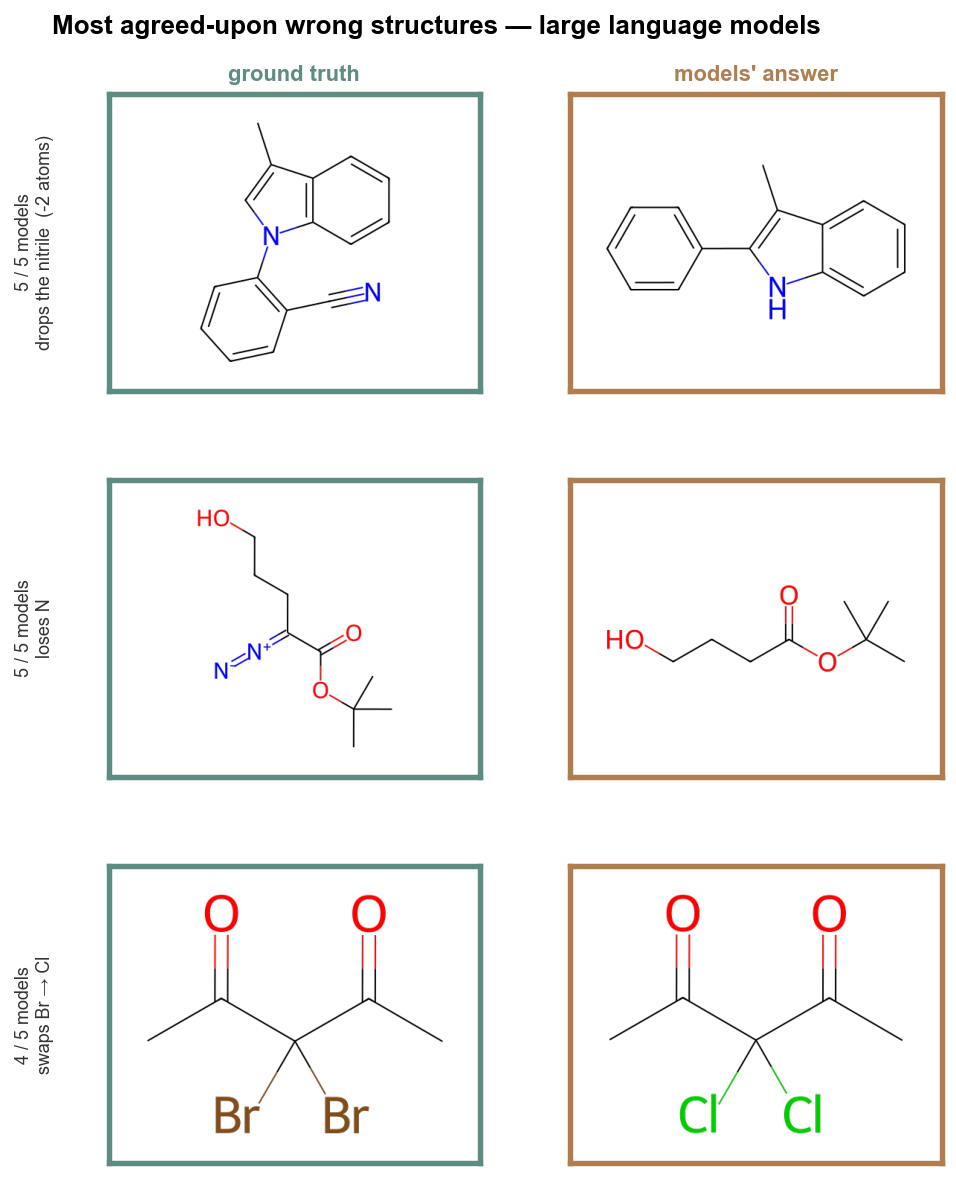

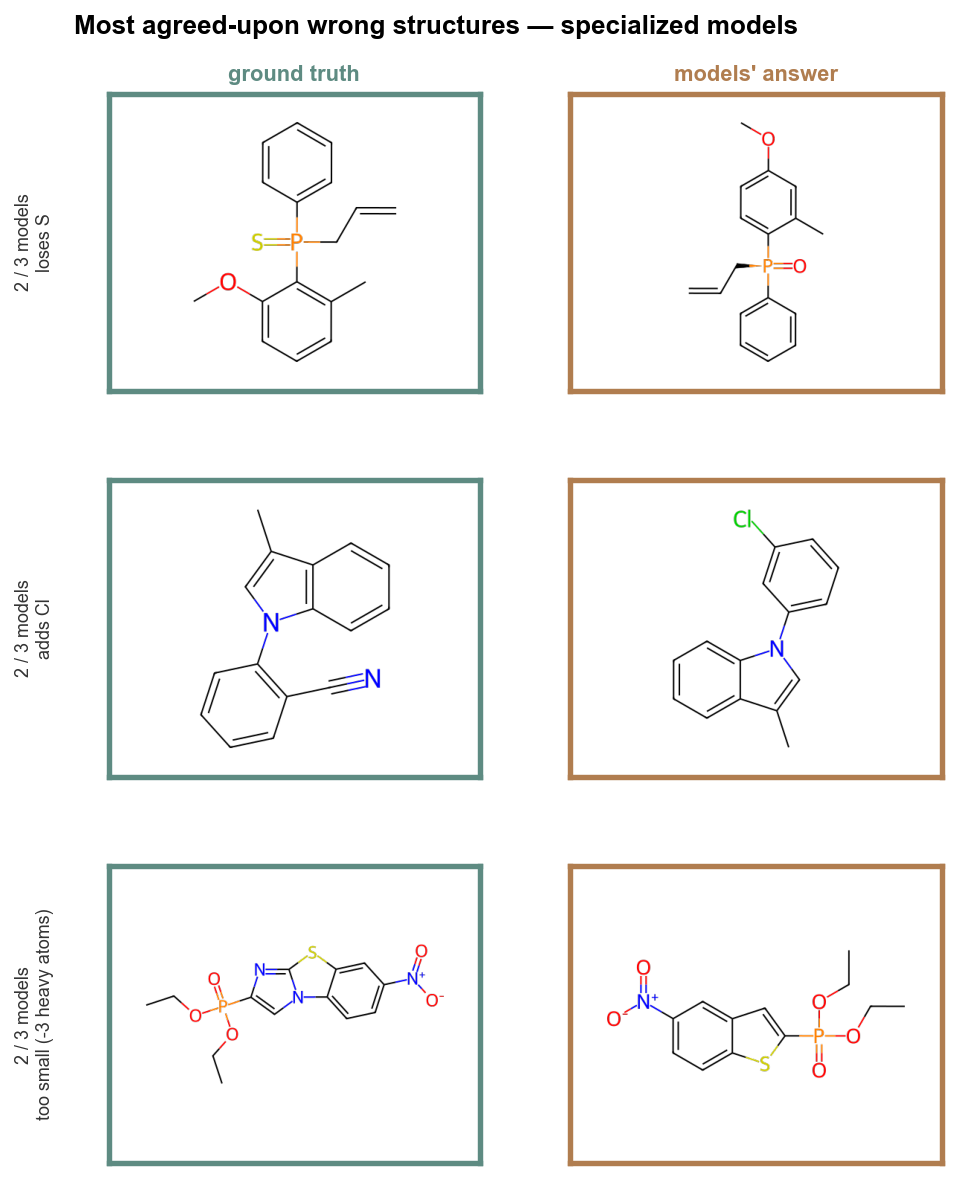

In [11]:
import io
from collections import defaultdict

from PIL import Image


# ---- structural descriptors (same definitions as analysis/nmr_analysis.py) ----
def _heavy(s):
    m = Chem.MolFromSmiles(s or ""); return m.GetNumHeavyAtoms() if m else None


def _elements(s):
    m = Chem.MolFromSmiles(s or "")
    return frozenset(a.GetSymbol() for a in m.GetAtoms()) if m else None


_FG_SMARTS = {
    "aromatic ring": "[a]", "ester": "[CX3](=O)[OX2H0][#6]", "aldehyde": "[CX3H1](=O)[#6,H]",
    "ketone": "[#6][CX3](=O)[#6]", "CF3": "[CX4](F)(F)F", "carboxylic acid": "[CX3](=O)[OX2H1]",
    "halogen": "[F,Cl,Br,I]", "sulfonyl": "[SX4](=O)(=O)", "nitrile": "[NX1]#[CX2]",
    "diazo": "[$([CX3]=[NX2+]=[NX1-]),$([CX2-]=[NX2+]=[NX1])]",
}
_FG_PAT = {k: Chem.MolFromSmarts(v) for k, v in _FG_SMARTS.items()}


def _has_fg(s, fg):
    m = Chem.MolFromSmiles(s or ""); return bool(m) and m.HasSubstructMatch(_FG_PAT[fg])


def error_label(t, p):
    """One-line auto description of how a wrong prediction differs from the truth."""
    et, ep = _elements(t), _elements(p)
    if et is not None and ep is not None and et != ep:
        lost, gained = et - ep, ep - et
        if lost and gained:
            return f"swaps {'/'.join(sorted(lost))} → {'/'.join(sorted(gained))}"
        if lost:
            return f"loses {'/'.join(sorted(lost))}"
        if gained:
            return f"adds {'/'.join(sorted(gained))}"
    dropped = [fg for fg in _FG_SMARTS if _has_fg(t, fg) and not _has_fg(p, fg)]
    dh = (_heavy(p) or 0) - (_heavy(t) or 0)
    if dropped:
        return f"drops the {dropped[0]}" + (f"  ({dh:+d} atoms)" if dh else "")
    if dh < 0:
        return f"too small ({dh:+d} heavy atoms)"
    if dh > 0:
        return f"too large ({dh:+d} heavy atoms)"
    return "wrong connectivity (isomer)"


def consensus_wrong(methods):
    """Group wrong-but-valid rank-1 answers by (molecule, wrong structure); count agreeing models.

    Returns cases sorted by consensus (how many models gave the same wrong molecule), ties broken
    by the smallest heavy-atom gap (closest near-misses first).
    """
    groups = defaultdict(lambda: {"models": set(), "truth": None, "pred": None})
    for rec in records:
        tc = canonical(rec["truth"])
        if tc is None:
            continue
        for m in methods:
            cands = rec["preds"][m]
            if not cands:
                continue
            pc = canonical(cands[0])
            if pc is None or pc == tc:
                continue
            g = groups[(rec["compound_id"], pc)]
            g["models"].add(m); g["truth"] = rec["truth"]; g["pred"] = cands[0]
    cases = [{"truth": g["truth"], "pred": g["pred"], "n": len(g["models"]), "models": sorted(g["models"])}
             for g in groups.values()]
    cases.sort(key=lambda c: (-c["n"], abs((_heavy(c["pred"]) or 0) - (_heavy(c["truth"]) or 0))))
    return cases


def _draw(smi, px=(500, 400)):
    """Render one molecule"""
    m = Chem.MolFromSmiles(smi)
    try:
        rdCoordGen.AddCoords(m)
    except Exception:
        rdDepictor.Compute2DCoords(m)
    d = rdMolDraw2D.MolDraw2DCairo(*px); o = d.drawOptions()
    o.padding = 0.10; o.bondLineWidth = 2; o.minFontSize = 9; o.maxFontSize = -1; o.clearBackground = False
    rdMolDraw2D.PrepareAndDrawMolecule(d, m); d.FinishDrawing()
    return Image.open(io.BytesIO(d.GetDrawingText())).convert("RGBA")


TRUTH_C, WRONG_C = GREEN["edge"], ORANGE["edge"]

def consensus_figure(methods, family, fname, k=3):
    cases = consensus_wrong(methods)[:k]
    ntot = len(methods)
    fig, axes = plt.subplots(len(cases), 2, figsize=(7.4, 2.7 * len(cases)))
    if len(cases) == 1:
        axes = axes.reshape(1, 2)
    fig.subplots_adjust(wspace=0.03, hspace=0.30, left=0.17, right=0.99, top=0.90, bottom=0.02)
    for r, c in enumerate(cases):
        for col, (smi, lab, color) in enumerate([(c["truth"], "ground truth", TRUTH_C),
                                                 (c["pred"], "models' answer", WRONG_C)]):
            ax = axes[r, col]; ax.imshow(_draw(smi)); ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values():
                s.set_visible(True); s.set_color(color); s.set_linewidth(2.6)
            if r == 0:
                ax.set_title(lab, color=color, fontsize=10.5, fontweight="bold", pad=6)
        agree = f"{c['n']} / {ntot} models" if c["n"] >= 2 else f"1 / {ntot} model"
        tag = f"{agree}\n{error_label(c['truth'], c['pred'])}"
        axes[r, 0].text(-0.20, 0.5, tag, transform=axes[r, 0].transAxes, rotation=90,
                        va="center", ha="center", fontsize=8.6, color="#333333", fontweight="medium")
    fig.suptitle(f"Most agreed-upon wrong structures — {family}",
                 fontsize=12.5, fontweight="bold", y=0.965)
    save_fig(fig, fname)
    plt.show()


# DeepSeek (mostly format-fails) and NMRMind (non-chemical output) carry no informative errors -> excluded here.
LLM_ERR  = [m for m in LLM if m != "deepseek"]
SPEC_ERR = [m for m in SPECIALIZED if m != "nmrmind"]
consensus_figure(LLM_ERR, "large language models", "fig_consensus_errors_llm", k=3)
consensus_figure(SPEC_ERR, "specialized models", "fig_consensus_errors_specialized", k=3)

### Functional-group fidelity: which groups each model type "reads"

A method can capture a structure's overall shape yet miscount a specific group: propose one ester
where there are two, or quietly drop a nitrile. For every functional group we take the molecules whose
true structure contains it and ask, across all of a method's TOP-N candidates, **how often the
prediction has the right number of that group**. (For aromatic heterocycles we match the number of ring
types; for 3- and 4-membered rings the count of each size; everything else is a direct count of
substructure matches.) A high score means the group leaves a clear NMR fingerprint the method
reproduces; a low score marks a "silent" group it keeps getting wrong. DeepSeek and NMRMind are excluded as unreliable.

In [12]:
LLM_FID  = [m for m in LLM if m != "deepseek"]            # DeepSeek excluded (unreliable)
SPEC_FID = [m for m in SPECIALIZED if m != "nmrmind"]     # NMRMind excluded (unreliable)

# --- functional groups: feature = count of unique SMARTS matches; match if pred count == truth count ---
_COUNT_SMARTS = {
    "ester": "[CX3](=O)[OX2H0][#6]",
    "aldehyde": "[CX3H1](=O)[#6,H]",
    "ketone": "[#6][CX3](=O)[#6]",
    "CF3": "[CX4](F)(F)F",
    "carboxylic acid": "[CX3](=O)[OX2H1]",
    "halogen": "[F,Cl,Br,I]",
    "sulfonyl": "[SX4](=O)(=O)",
    "nitrile": "[NX1]#[CX2]",
    "ether": "[#6;!$([CX3]=[OX1])][OX2H0][#6;!$([CX3]=[OX1])]",
    "amine": "[NX3;!$([NX3][CX3]=[OX1]);!$([NX3]=*);!$([N+])][CX4]",
    "amide": "[#6X3](=[OX1])[#7X3]",
}
_COUNT_PAT = {k: Chem.MolFromSmarts(v) for k, v in _COUNT_SMARTS.items()}

# aromatic heterocycles: feature = number of distinct ring TYPES present (not total count)
_HETEROARENE = ["c1ccncc1", "c1cc[n]c1", "c1ccoc1", "c1ccsc1", "c1c[n]cn1",
                "[c;r5]1[c;r5][n;r5][n;r5][n;r5]1", "[c;r5]1[n;r5][c;r5][n;r5][n;r5]1"]
_HA_PAT = [Chem.MolFromSmarts(s) for s in _HETEROARENE]

GROUPS = list(_COUNT_SMARTS) + ["aromatic heterocycle", "small rings"]
DISPLAY_G = {"CF3": "CF$_3$"}


def _count(mol, patt):
    return len(mol.GetSubstructMatches(patt, uniquify=True))


def _ha_types(mol):
    return sum(1 for p in _HA_PAT if mol.HasSubstructMatch(p))


def _small_rings(mol):
    """(number of 3-membered rings, number of 4-membered rings)."""
    n3 = n4 = 0
    for ring in mol.GetRingInfo().AtomRings():
        if len(ring) == 3:
            n3 += 1
        elif len(ring) == 4:
            n4 += 1
    return (n3, n4)


def _truth_has(mol, g):
    if g in _COUNT_SMARTS:
        return _count(mol, _COUNT_PAT[g]) >= 1
    if g == "aromatic heterocycle":
        return _ha_types(mol) >= 1
    return sum(_small_rings(mol)) >= 1


def _match(t, p, g):
    """Same number of the group in prediction and truth (small rings: same per-size count)."""
    if g in _COUNT_SMARTS:
        return _count(t, _COUNT_PAT[g]) == _count(p, _COUNT_PAT[g])
    if g == "aromatic heterocycle":
        return _ha_types(t) == _ha_types(p)
    return _small_rings(t) == _small_rings(p)


# precompute truth mol + valid prediction mols per method (invalid predictions dropped)
_proc = []
for rec in records:
    tmol = Chem.MolFromSmiles(rec["truth"] or "")
    if tmol is None:
        continue
    pm = {m: [x for x in (Chem.MolFromSmiles(s) for s in rec["preds"][m]) if x is not None]
          for m in LLM_FID + SPEC_FID}
    _proc.append((tmol, pm))


def group_fidelity(cohort, g):
    """% of TOP-N predictions (pooled over the cohort's models) with the correct group count,
    among molecules whose true structure contains the group."""
    matches = total = 0
    for tmol, pm in _proc:
        if not _truth_has(tmol, g):
            continue
        for m in cohort:
            for pmol in pm[m]:
                total += 1
                matches += _match(tmol, pmol, g)
    return (100.0 * matches / total) if total else float("nan")


fid = {"LLM":  {g: group_fidelity(LLM_FID, g)  for g in GROUPS},
       "SPEC": {g: group_fidelity(SPEC_FID, g) for g in GROUPS}}

#### All functional groups at a glance

Each group has two dots — LLMs
(orange) and specialized tools (green), joined by a line: the line length is the gap between them,
and which dot sits further right tells which model type senses that group better. Groups are ordered
top-to-bottom from best- to worst-sensed, so the readability gradient (loud → silent groups) reads
straight down the figure

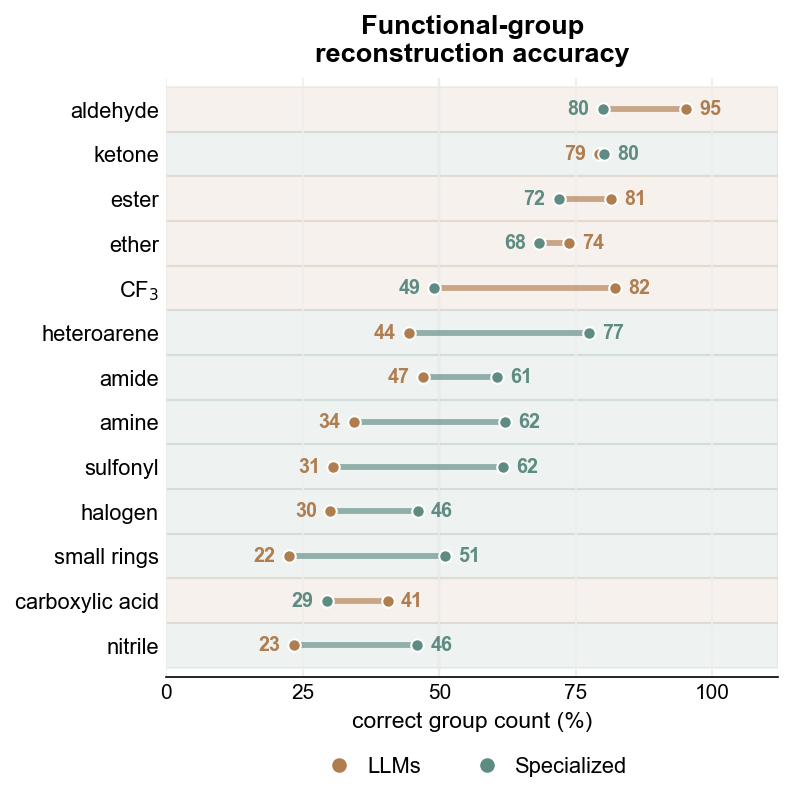

In [13]:
LLM_C, SPEC_C = ORANGE["edge"], GREEN["edge"]

order = sorted(GROUPS, key=lambda g: (fid["LLM"][g] + fid["SPEC"][g]) / 2, reverse=True)
ypos = np.arange(len(order))[::-1]          

fig, ax = plt.subplots(figsize=(5.4, 5.7))                              
fig.subplots_adjust(left=0.22, right=0.975, top=0.86, bottom=0.16)
ax.axvline(50, color="#e8e8e8", lw=1.1, zorder=0)                       
DISP = {**DISPLAY_G, "aromatic heterocycle": "heteroarene"}            

for g, y in zip(order, ypos):
    l, s = fid["LLM"][g], fid["SPEC"][g]
    win_c = LLM_C if l >= s else SPEC_C                                  
    ax.axhspan(y - 0.5, y + 0.5, color=win_c, alpha=0.10, zorder=0)      
    ax.plot([l, s], [y, y], color=win_c, lw=2.8, alpha=0.65, solid_capstyle="round", zorder=2)
    ax.scatter([l], [y], s=36, color=LLM_C, edgecolor="white", linewidth=1.0, zorder=3)
    ax.scatter([s], [y], s=36, color=SPEC_C, edgecolor="white", linewidth=1.0, zorder=3)
    (lo_v, lo_c), (hi_v, hi_c) = sorted([(l, LLM_C), (s, SPEC_C)], key=lambda t: t[0])
    ax.text(lo_v - 2.4, y, f"{lo_v:.0f}", ha="right", va="center", fontsize=9.5, color=lo_c, fontweight="bold")
    ax.text(hi_v + 2.4, y, f"{hi_v:.0f}", ha="left",  va="center", fontsize=9.5, color=hi_c, fontweight="bold")

ax.set_yticks(ypos); ax.set_yticklabels([DISP.get(g, g) for g in order], fontsize=10.5)
ax.set_xlim(0, 112); ax.set_ylim(-0.7, len(order) - 0.3)
ax.set_xticks(range(0, 101, 25)); ax.tick_params(axis="x", labelsize=10)
ax.set_xlabel("correct group count (%)", fontsize=11)
ax.set_axisbelow(True); ax.xaxis.grid(True, color="#eeeeee", lw=0.8)
for sp in ("top", "right", "left"):
    ax.spines[sp].set_visible(False)
ax.tick_params(length=0)
ax.set_title("Functional-group\nreconstruction accuracy", fontsize=13, fontweight="bold", pad=8)
ax.legend(handles=[Line2D([0], [0], marker="o", color="none", markerfacecolor=LLM_C,
                          markeredgecolor="white", markersize=8, label="LLMs"),
                   Line2D([0], [0], marker="o", color="none", markerfacecolor=SPEC_C,
                          markeredgecolor="white", markersize=8, label="Specialized")],
          loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=False,
          fontsize=10.5, handletextpad=0.3, columnspacing=2.0)
save_fig(fig, "fig_group_fidelity_all")
plt.show()

#### Same chart, presence-only metric

The chart above credits a prediction only when it has the exact same number of a group as the
truth. Here we relax that to presence: among molecules whose true structure contains a group, we
count what fraction of a method's TOP-N predictions contain **at least one** of that group. For example, CF3 is "found" whenever the truth had any number of CF3 groups and the prediction carries one or more; likewise a heteroarene or a small ring scores as soon as the prediction
has one at all.

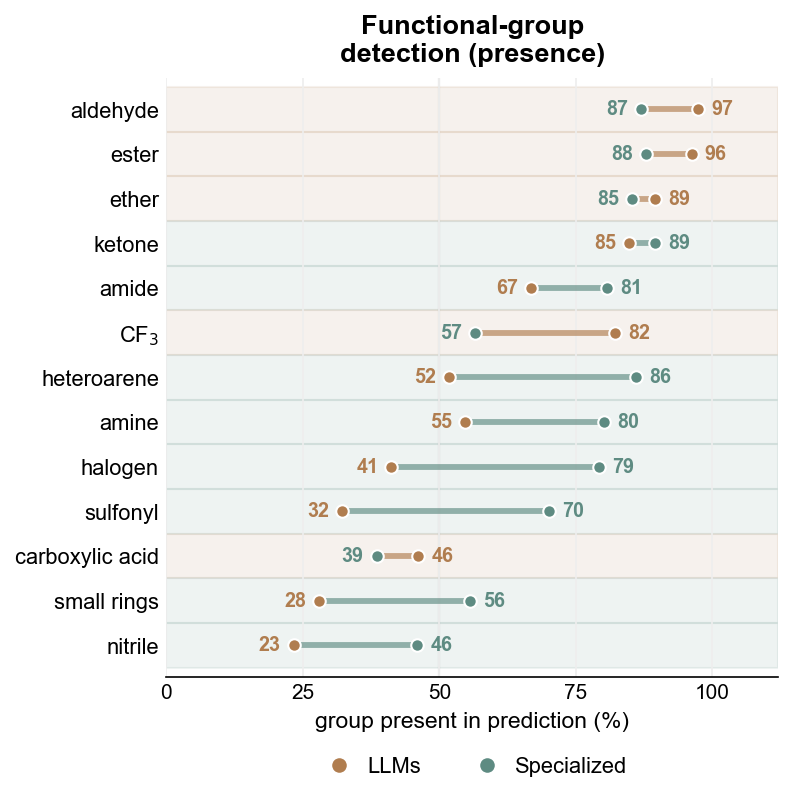

In [14]:
# --- ALTERNATIVE METRIC: group PRESENCE (not count) ---
def _match_presence(t, p, g):
    """True if the prediction contains the group at all (>=1), regardless of how many."""
    if g in _COUNT_SMARTS:
        return _count(p, _COUNT_PAT[g]) >= 1
    if g == "aromatic heterocycle":
        return _ha_types(p) >= 1
    return sum(_small_rings(p)) >= 1


def group_presence(cohort, g):
    """% of TOP-N predictions (pooled over the cohort's models) that contain the group at all,
    among molecules whose true structure contains the group."""
    matches = total = 0
    for tmol, pm in _proc:
        if not _truth_has(tmol, g):
            continue
        for m in cohort:
            for pmol in pm[m]:
                total += 1
                matches += _match_presence(tmol, pmol, g)
    return (100.0 * matches / total) if total else float("nan")


fid_pres = {"LLM":  {g: group_presence(LLM_FID, g)  for g in GROUPS},
            "SPEC": {g: group_presence(SPEC_FID, g) for g in GROUPS}}

LLM_C, SPEC_C = ORANGE["edge"], GREEN["edge"]

order = sorted(GROUPS, key=lambda g: (fid_pres["LLM"][g] + fid_pres["SPEC"][g]) / 2, reverse=True)
ypos = np.arange(len(order))[::-1]   

fig, ax = plt.subplots(figsize=(5.4, 5.7))                              
fig.subplots_adjust(left=0.22, right=0.975, top=0.86, bottom=0.16)
ax.axvline(50, color="#e8e8e8", lw=1.1, zorder=0)                      
DISP = {**DISPLAY_G, "aromatic heterocycle": "heteroarene"}             

for g, y in zip(order, ypos):
    l, s = fid_pres["LLM"][g], fid_pres["SPEC"][g]
    win_c = LLM_C if l >= s else SPEC_C                                  
    ax.axhspan(y - 0.5, y + 0.5, color=win_c, alpha=0.10, zorder=0)      
    ax.plot([l, s], [y, y], color=win_c, lw=2.8, alpha=0.65, solid_capstyle="round", zorder=2)
    ax.scatter([l], [y], s=36, color=LLM_C, edgecolor="white", linewidth=1.0, zorder=3)
    ax.scatter([s], [y], s=36, color=SPEC_C, edgecolor="white", linewidth=1.0, zorder=3)
    (lo_v, lo_c), (hi_v, hi_c) = sorted([(l, LLM_C), (s, SPEC_C)], key=lambda t: t[0])
    ax.text(lo_v - 2.4, y, f"{lo_v:.0f}", ha="right", va="center", fontsize=9.5, color=lo_c, fontweight="bold")
    ax.text(hi_v + 2.4, y, f"{hi_v:.0f}", ha="left",  va="center", fontsize=9.5, color=hi_c, fontweight="bold")

ax.set_yticks(ypos); ax.set_yticklabels([DISP.get(g, g) for g in order], fontsize=10.5)
ax.set_xlim(0, 112); ax.set_ylim(-0.7, len(order) - 0.3)
ax.set_xticks(range(0, 101, 25)); ax.tick_params(axis="x", labelsize=10)
ax.set_xlabel("group present in prediction (%)", fontsize=11)
ax.set_axisbelow(True); ax.xaxis.grid(True, color="#eeeeee", lw=0.8)
for sp in ("top", "right", "left"):
    ax.spines[sp].set_visible(False)
ax.tick_params(length=0)
ax.set_title("Functional-group\ndetection (presence)", fontsize=13, fontweight="bold", pad=8)
ax.legend(handles=[Line2D([0], [0], marker="o", color="none", markerfacecolor=LLM_C,
                          markeredgecolor="white", markersize=8, label="LLMs"),
                   Line2D([0], [0], marker="o", color="none", markerfacecolor=SPEC_C,
                          markeredgecolor="white", markersize=8, label="Specialized")],
          loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=False,
          fontsize=10.5, handletextpad=0.3, columnspacing=2.0)
save_fig(fig, "fig_group_presence_all")
plt.show()

### Per-class Top-1 accuracy

Top-1 accuracy (%) for all ten systems across the 21 functional-group classes (5 molecules per class, so every cell steps in 20% increments). The horizontal rule separates the four specialized tools (top) from the six general LLMs.

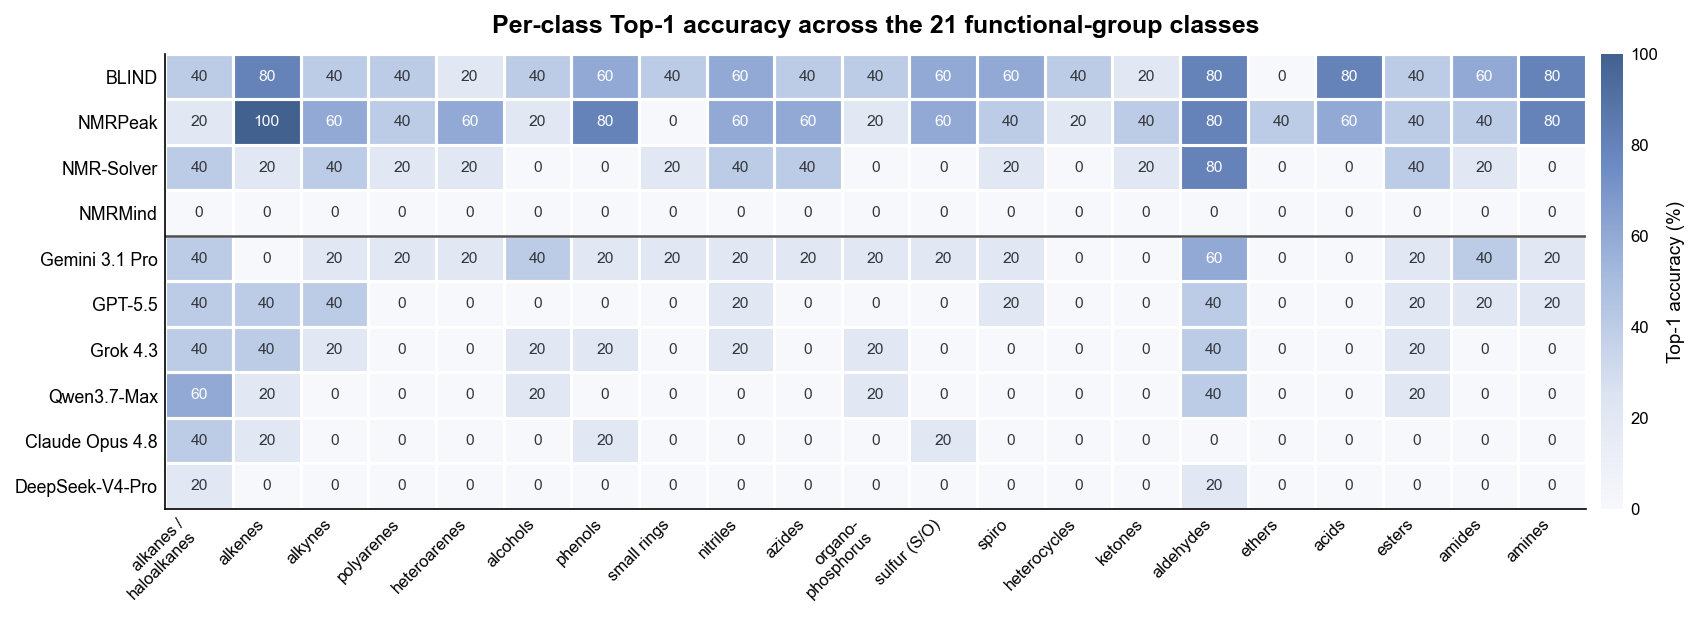

In [15]:


CLASSES = list(raw.keys())                                       # 21 functional-group classes, paper order
CLS_LABEL = {
    "cls_alkanes_haloalkanes": "alkanes /\nhaloalkanes", "cls_alkenes": "alkenes", "cls_alkynes": "alkynes",
    "cls_polyarenes": "polyarenes", "cls_heteroarenes": "heteroarenes", "cls_alcohols": "alcohols",
    "cls_phenols": "phenols", "cls_small_rings": "small rings", "cls_nitriles": "nitriles", "cls_azides": "azides",
    "cls_organophosphorus": "organo-\nphosphorus", "cls_sulfur_so": "sulfur (S/O)", "cls_spiro": "spiro",
    "cls_heterocycles": "heterocycles", "cls_ketones": "ketones", "cls_aldehydes": "aldehydes",
    "cls_ethers": "ethers", "cls_acids": "acids", "cls_esters": "esters", "cls_amides": "amides", "cls_amines": "amines",
}
by_cls = {c: [r for r in records if r["cls"] == c] for c in CLASSES}


acc = np.array([[100.0 * sum(hit_rank(r["truth"], r["preds"][m]) == 1 for r in by_cls[c]) / len(by_cls[c])
                 for c in CLASSES] for m in METHODS])

CMAP = LinearSegmentedColormap.from_list("acc", ["#F7F8FC", "#DCE3F1", "#A9BDDF", "#6E8CC4", "#42618F"])

fig, ax = plt.subplots(figsize=(11.2, 4.6))
fig.subplots_adjust(left=0.12, right=0.99, top=0.90, bottom=0.24)
im = ax.imshow(acc, cmap=CMAP, vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels([CLS_LABEL[c] for c in CLASSES], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(METHODS))); ax.set_yticklabels([DISPLAY[m] for m in METHODS], fontsize=8.5)
ax.set_xticks(np.arange(-0.5, len(CLASSES), 1), minor=True)          
ax.set_yticks(np.arange(-0.5, len(METHODS), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", length=0); ax.tick_params(which="major", length=0)
ax.axhline(len(SPECIALIZED) - 0.5, color="#4d4d4d", lw=1.2)          

for i in range(len(METHODS)):
    for j in range(len(CLASSES)):
        v = acc[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5, color="white" if v >= 60 else "#33373d")

cb = fig.colorbar(im, ax=ax, fraction=0.018, pad=0.01)
cb.set_label("Top-1 accuracy (%)", fontsize=9); cb.outline.set_visible(False); cb.ax.tick_params(labelsize=8, length=0)
ax.set_title("Per-class Top-1 accuracy across the 21 functional-group classes", fontsize=12, fontweight="bold", pad=10)
save_fig(fig, "fig_perclass_top1_heatmap")
plt.show()

### Structural closeness of the best answer

Distribution of the Top-1 Tanimoto similarity (Morgan radius 2 / ECFP4) between each system's rank-1 candidate and the true molecule. Boxes are coloured by family (green = specialized, orange = LLM).

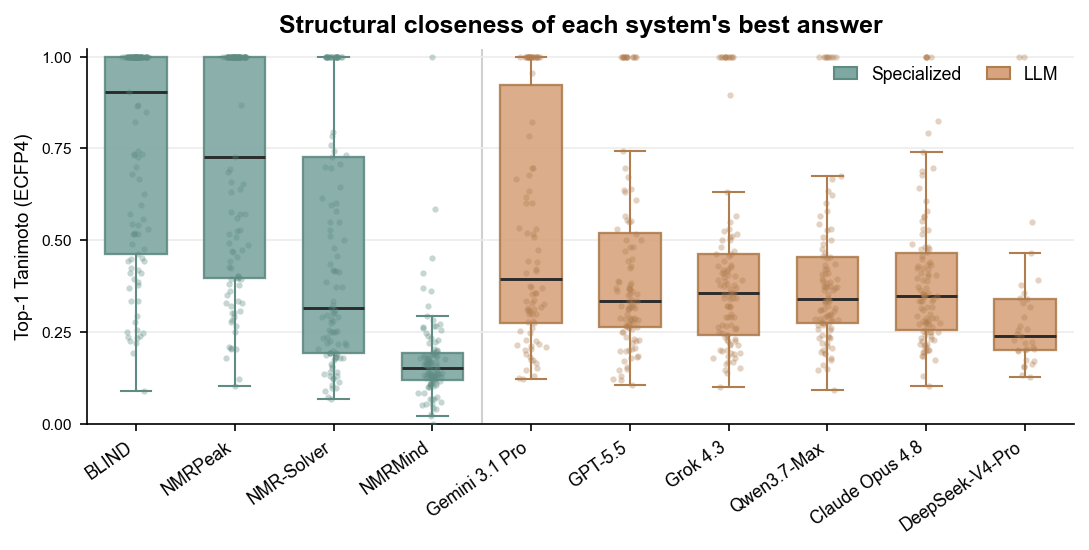

In [16]:
np.random.seed(0)                                                # reproducible jitter
data, fams = [], []
for m in METHODS:
    vals = [tanimoto(r["truth"], r["preds"][m][0]) for r in records if r["preds"][m]]
    data.append([v for v in vals if v is not None])
    fams.append(GREEN if m in SPECIALIZED else ORANGE)

fig, ax = plt.subplots(figsize=(7.4, 3.9))
fig.subplots_adjust(left=0.09, right=0.98, top=0.86, bottom=0.22)
bp = ax.boxplot(data, widths=0.62, patch_artist=True, showfliers=False, medianprops=dict(color="#2b2b2b", lw=1.4))
for patch, fam in zip(bp["boxes"], fams):
    patch.set_facecolor(fam["solid"]); patch.set_edgecolor(fam["edge"]); patch.set_linewidth(1.1); patch.set_alpha(0.9)
for key in ("whiskers", "caps"):
    for ln, fam in zip(bp[key], [f for f in fams for _ in (0, 1)]):
        ln.set_color(fam["edge"]); ln.set_linewidth(1.0)
for i, (vals, fam) in enumerate(zip(data, fams), start=1):        # jittered raw points
    ax.scatter(np.random.normal(i, 0.055, len(vals)), vals, s=9, color=fam["edge"], alpha=0.35, linewidths=0, zorder=3)

ax.axvline(len(SPECIALIZED) + 0.5, color="#d0d0d0", lw=1.0, zorder=0)   # specialized | LLM divider
ax.set_xticks(range(1, len(METHODS) + 1)); ax.set_xticklabels([DISPLAY[m] for m in METHODS], rotation=35, ha="right", fontsize=8.5)
ax.set_ylim(0, 1.02); ax.set_yticks(np.arange(0, 1.01, 0.25)); ax.set_ylabel("Top-1 Tanimoto (ECFP4)")
ax.yaxis.grid(True, color="#ececec", lw=0.8); ax.set_axisbelow(True)
ax.legend(handles=[Patch(facecolor=GREEN["solid"], edgecolor=GREEN["edge"], label="Specialized"),
                   Patch(facecolor=ORANGE["solid"], edgecolor=ORANGE["edge"], label="LLM")],
          loc="upper right", frameon=False, fontsize=8.5, ncol=2, handlelength=1.3, columnspacing=1.4)
ax.set_title("Structural closeness of each system's best answer", fontsize=12, fontweight="bold", pad=8)
save_fig(fig, "fig_top1_tanimoto_box")
plt.show()

### Accuracy vs molecular complexity

How does the chance of solving a structure fall as the molecule gets more complex? We bin the 105
molecules into the five complexity quintiles (Q1 easiest → Q5 hardest, 21 molecules each) and, pooling
every compound–model prediction within each family, show the fully-solved (Top-1) rate as the solid
bar and the Top-10 reach as a light cap above it. DeepSeek and NMRMind are excluded.

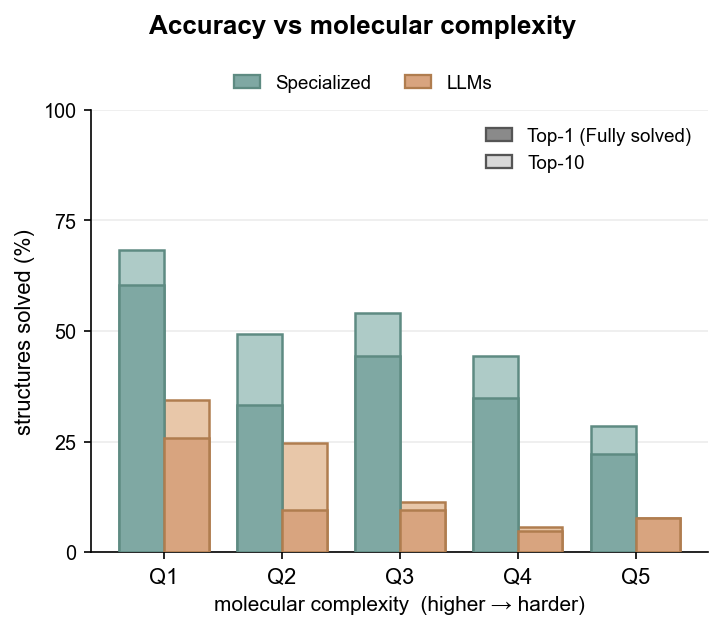

In [17]:
LLM_CX  = [m for m in LLM if m != "deepseek"]
SPEC_CX = [m for m in SPECIALIZED if m != "nmrmind"]
PAL = {"Specialized": dict(cap=GREEN["cap"],  solid=GREEN["solid"],  edge=GREEN["edge"]),
       "LLM":         dict(cap=ORANGE["cap"], solid=ORANGE["solid"], edge=ORANGE["edge"])}
QUINT = [1, 2, 3, 4, 5]
cohorts = [("Specialized", SPEC_CX), ("LLM", LLM_CX)]

# hit rank once per (compound, model), grouped by complexity quintile (the record key 1.0..5.0)
ranks = {q: {coh: [] for coh, _ in cohorts} for q in QUINT}
for rec in records:
    q = int(float(rec["entry_id"]))
    if q not in ranks:
        continue
    for coh, methods in cohorts:
        for m in methods:
            ranks[q][coh].append(hit_rank(rec["truth"], rec["preds"][m]))


def rate(coh, q, k):
    rs = ranks[q][coh]
    return 100.0 * sum(1 for r in rs if r is not None and r <= k) / len(rs) if rs else 0.0


x = np.arange(len(QUINT)); w = 0.38
off = {"Specialized": -w / 2, "LLM": +w / 2}

fig, ax = plt.subplots(figsize=(4.9, 4.4))
fig.subplots_adjust(left=0.13, right=0.97, top=0.82, bottom=0.15)

for coh, _ in cohorts:
    t1  = [rate(coh, q, 1)  for q in QUINT]
    t10 = [rate(coh, q, 10) for q in QUINT]
    p = PAL[coh]
    ax.bar(x + off[coh], t10, w, color=p["cap"],   edgecolor=p["edge"], linewidth=1.2, zorder=2)
    ax.bar(x + off[coh], t1,  w, color=p["solid"], edgecolor=p["edge"], linewidth=1.2, zorder=3)

ax.set_xticks(x); ax.set_xticklabels([f"Q{q}" for q in QUINT], fontsize=10.5)
ax.set_xlabel("molecular complexity  (higher → harder)", fontsize=10)
ax.set_ylabel("structures solved (%)", fontsize=10.5)
ax.set_ylim(0, 100); ax.set_yticks(range(0, 101, 25)); ax.tick_params(axis="y", labelsize=9.5)
ax.yaxis.grid(True, color="#ececec", lw=0.8); ax.set_axisbelow(True)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)

fig.text(0.5, 0.965, "Accuracy vs molecular complexity", fontsize=12.5, fontweight="bold", ha="center", va="top")
fig.legend(handles=[Patch(facecolor=PAL["Specialized"]["solid"], edgecolor=PAL["Specialized"]["edge"], linewidth=1.1, label="Specialized"),
                    Patch(facecolor=PAL["LLM"]["solid"], edgecolor=PAL["LLM"]["edge"], linewidth=1.1, label="LLMs")],
           loc="upper center", bbox_to_anchor=(0.5, 0.90), ncol=2,
           frameon=False, fontsize=9, handlelength=1.4, columnspacing=1.8)

ax.legend(handles=[Patch(facecolor="#8a8a8a", edgecolor="#555555", linewidth=1.1, label="Top-1 (Fully solved)"),
                   Patch(facecolor="#d9d9d9", edgecolor="#555555", linewidth=1.1, label="Top-10")],
          loc="upper right", frameon=False, fontsize=9, handlelength=1.4)
save_fig(fig, "fig_complexity_quintile_bars")
plt.show()

### Invalid-structure rate

This is separate from *accuracy*. It asks how often a method proposes a structure that **cannot exist
as a real molecule**: impossible valences, broken rings, garbled atoms, rather than the wrong (but
chemically real) compound. Every candidate a method generated is checked with RDKit; the bars show the
percentage that are not valid molecules, with a per-type mean (hatched) on the right.

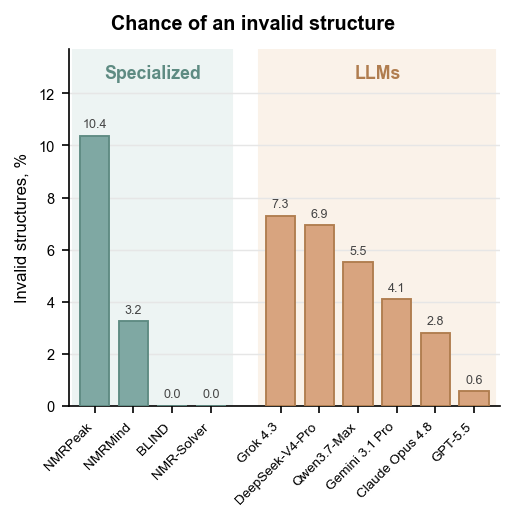

In [18]:
def is_valid(s):
    """A structure is valid if RDKit can build a real molecule from it (correct valences, intact rings)."""
    return bool(s) and Chem.MolFromSmiles(s) is not None


# ---- invalid-structure rate per method, over every candidate the method proposed ----
total   = {m: 0 for m in METHODS}
invalid = {m: 0 for m in METHODS}
for rec in records:
    for m in METHODS:
        for s in rec["preds"][m]:
            total[m]   += 1
            invalid[m] += 0 if is_valid(s) else 1

df = pd.DataFrame({"model": METHODS,
                   "label": [DISPLAY[m] for m in METHODS],
                   "type":  ["Specialized" if m in SPECIALIZED else "LLM" for m in METHODS],
                   "total": [total[m] for m in METHODS],
                   "invalid": [invalid[m] for m in METHODS]})
df["rate"] = np.where(df["total"] > 0, df["invalid"] / df["total"] * 100, 0.0)

PAL = {"Specialized": dict(fill=GREEN["solid"],  edge=GREEN["edge"],  tint=GREEN["band"]),
       "LLM":         dict(fill=ORANGE["solid"], edge=ORANGE["edge"], tint=ORANGE["band"])}
GROUP_GAP = 0.8

spec = df[df.type == "Specialized"].sort_values("rate", ascending=False)
llm  = df[df.type == "LLM"].sort_values("rate", ascending=False)

xs, labels, fills, edges = [], [], [], []
cur = 0.0; spec_x0 = cur
for _, r in spec.iterrows():
    xs.append(cur); labels.append(r["label"]); fills.append(PAL["Specialized"]["fill"]); edges.append(PAL["Specialized"]["edge"]); cur += 1
spec_x1 = cur - 1; cur += GROUP_GAP; llm_x0 = cur
for _, r in llm.iterrows():
    xs.append(cur); labels.append(r["label"]); fills.append(PAL["LLM"]["fill"]); edges.append(PAL["LLM"]["edge"]); cur += 1
llm_x1 = cur - 1
rates = list(spec["rate"]) + list(llm["rate"])
ymax = max(rates)

fig, ax = plt.subplots(figsize=(3.5, 3.6))
ax.axvspan(spec_x0 - 0.55, spec_x1 + 0.55, color=PAL["Specialized"]["tint"], zorder=0)
ax.axvspan(llm_x0 - 0.55,  llm_x1 + 0.55,  color=PAL["LLM"]["tint"],         zorder=0)
ax.bar(xs, rates, width=0.76, color=fills, edgecolor=edges, lw=0.9, zorder=3)
for x, v in zip(xs, rates):
    ax.text(x, v + ymax * 0.02, f"{v:.1f}", ha="center", va="bottom", fontsize=6, color="#444")

ax.set_xticks(xs)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=6.5)
ax.text((spec_x0 + spec_x1) / 2, ymax * 1.20, "Specialized", ha="center", va="bottom",
        fontsize=8.5, fontweight="bold", color=PAL["Specialized"]["edge"])
ax.text((llm_x0 + llm_x1) / 2, ymax * 1.20, "LLMs", ha="center", va="bottom",
        fontsize=8.5, fontweight="bold", color=PAL["LLM"]["edge"])
ax.set_ylabel("Invalid structures, %", fontsize=8); ax.set_ylim(0, ymax * 1.32)
ax.yaxis.grid(True, color="#e6e6e6", lw=0.7, zorder=0); ax.set_axisbelow(True); ax.margins(x=0.01)
ax.tick_params(axis="y", labelsize=7)

fig.text(0.5, 0.965, "Chance of an invalid structure", fontsize=9.5, fontweight="bold", ha="center", va="top")
fig.subplots_adjust(top=0.90, bottom=0.24, left=0.15, right=0.97)
save_fig(fig, "fig_invalid_structure_rate")
plt.show()
